# Evaluasi dan Perbandingan Kinerja Model LSTM dan GRU

---

Notebook ini merupakan tahap keenam dari pipeline *image captioning*. Setelah kedua model (CNN+LSTM dan CNN+GRU) berhasil dilatih, langkah selanjutnya adalah mengevaluasi dan membandingkan kinerja keduanya secara kuantitatif menggunakan metrik **BLEU Score** pada data uji yang telah dipisahkan.

## Latar Belakang dan Tujuan

Evaluasi model merupakan tahap kritis dalam pengembangan sistem *machine learning*. Tanpa evaluasi yang objektif, kita tidak dapat menentukan apakah model yang dilatih benar-benar efektif atau hanya menghafal data latih (*overfitting*).

Notebook ini bertujuan untuk:
- Menghasilkan *caption* prediksi untuk 810 gambar data uji menggunakan kedua model (LSTM dan GRU) dengan *greedy decoding*;
- Menghitung skor BLEU-1 hingga BLEU-4 untuk kedua model;
- Membandingkan performa LSTM vs GRU secara visual dan numerik;
- Menyimpan hasil evaluasi untuk dokumentasi dan pelaporan.

## Dasar Teori

### BLEU Score

BLEU (*Bilingual Evaluation Understudy*) adalah metrik yang mengukur kesamaan antara teks hasil prediksi mesin dengan satu atau lebih teks referensi manusia. BLEU Score dihitung berdasarkan *precision* dari n-gram (urutan n kata) yang cocok antara kandidat dan referensi:

$$
\text{BLEU-n} = \text{BP} \cdot \exp\left( \sum_{k=1}^{n} w_k \log p_k \right)
$$

di mana:
- $p_k$ adalah *precision* untuk n-gram dengan panjang $k$ (jumlah n-gram kandidat yang cocok dibagi total n-gram kandidat);
- $w_k$ adalah bobot (biasanya seragam, $1/n$);
- $\text{BP}$ (*Brevity Penalty*) adalah faktor penalti untuk *caption* yang lebih pendek dari referensi.

| Metrik | Definisi | Makna |
|--------|----------|-------|
| BLEU-1 | Unigram (kata tunggal) | Ketepatan pemilihan kata |
| BLEU-2 | Bigram (2 kata) | Kelancaran frasa pendek |
| BLEU-3 | Trigram (3 kata) | Koherensi lokal |
| BLEU-4 | 4-gram (4 kata) | Struktur kalimat secara umum |

### Smoothing Function

BLEU *score* menggunakan metode *smoothing* (method4 dari NLTK) untuk menghindari skor nol ketika tidak ada n-gram yang cocok — sebuah situasi yang sering terjadi pada *caption* pendek atau saat model menghasilkan kata-kata yang berbeda secara signifikan dari referensi.

## Impor Pustaka

In [1]:
import os
import re
import pickle
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import sys
sys.path.append("..")
from src.evaluation.metrics import compute_bleu, format_bleu_report

2026-07-19 17:38:52.848796: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-19 17:38:52.860757: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-19 17:38:52.871351: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-19 17:38:52.874502: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-19 17:38:52.884037: I tensorflow/core/platform/cpu_feature_guar

## Konfigurasi GPU

Inferensi dapat memanfaatkan GPU meskipun tidak wajib. Konfigurasi GPU sama dengan notebook pelatihan: *memory growth* dan *mixed precision*.

In [2]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU:", gpus[0].name)

GPU: /physical_device:GPU:0


I0000 00:00:1784457536.872702  349930 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784457536.914806  349930 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784457536.916331  349930 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


## Konfigurasi

In [3]:
CAPTIONS_PATH = "../dataset/captions.txt"
FEATURES_PATH = "../model/features.pkl"

LSTM_DIR = "../outputs/training/lstm"
GRU_DIR  = "../outputs/training/gru"
EVAL_DIR = "../outputs/evaluation"
os.makedirs(EVAL_DIR, exist_ok=True)

VOCAB_SIZE      = 5000
MAX_CAPTION_LEN = 34
TEST_SIZE       = 0.1
RANDOM_SEED     = 42

## Metodologi Implementasi

### 6.1 Memuat Dataset

Dataset *caption* dimuat dari `dataset/captions.txt`. Data akan dibersihkan dan dibagi dengan cara yang identik dengan notebook pelatihan untuk memastikan perbandingan yang adil.

In [4]:
df = pd.read_csv(CAPTIONS_PATH)
print(f"Captions loaded: {len(df):,}")

Captions loaded: 40,455


### 6.2 Pembersihan dan Pembagian Data Uji

Pipeline pembersihan yang identik dengan notebook 02 dan 04/05 digunakan untuk memastikan konsistensi. Data uji diambil sebagai 10% gambar terakhir (sama seperti pada notebook pelatihan).

In [5]:
def clean_caption(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z ]", "", text)
    return text.strip()

df["clean"] = df["caption"].apply(clean_caption)

unique_images = df["image"].unique()
train_imgs, test_imgs = train_test_split(
    unique_images, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

test_mask = df["image"].isin(test_imgs)
test_df = df[test_mask].copy()

print(f"Test images:  {len(test_imgs):,}")
print(f"Test captions: {len(test_df):,}")
print(f"Captions per image: {len(test_df) // len(test_imgs)}")

Test images:  810
Test captions: 4,050
Captions per image: 5


### 6.3 Memuat Fitur Gambar

In [6]:
with open(FEATURES_PATH, "rb") as f:
    features = pickle.load(f)
print(f"Features loaded: {len(features)} images")

# Filter to test images only
test_features = {name: features[name] for name in test_imgs}
print(f"Test features:  {len(test_features)} images")

Features loaded: 8091 images
Test features:  810 images


### 6.4 Memuat Kedua Model dan Tokenizer

Model LSTM dan GRU beserta tokenizer masing-masing dimuat dari direktori `outputs/training/`. Setiap model memiliki tokenizer sendiri yang di-*fit* pada data latih.

In [7]:
# LSTM
lstm_path = os.path.join(LSTM_DIR, "lstm_best.keras")
if not os.path.exists(lstm_path):
    raise FileNotFoundError(
        f"LSTM model not found at {lstm_path}. Run 04_train_lstm.ipynb first."
    )
lstm_model = tf.keras.models.load_model(lstm_path)
print(f"LSTM loaded: {lstm_model.count_params():,} params")

with open(os.path.join(LSTM_DIR, "tokenizer.pkl"), "rb") as f:
    lstm_tokenizer = pickle.load(f)
print(f"LSTM tokenizer vocab: {len(lstm_tokenizer.word_index)}")

# GRU
gru_path = os.path.join(GRU_DIR, "gru_best.keras")
if not os.path.exists(gru_path):
    raise FileNotFoundError(
        f"GRU model not found at {gru_path}. Run 05_train_gru.ipynb first."
    )
gru_model = tf.keras.models.load_model(gru_path)
print(f"GRU loaded:   {gru_model.count_params():,} params")

with open(os.path.join(GRU_DIR, "tokenizer.pkl"), "rb") as f:
    gru_tokenizer = pickle.load(f)
print(f"GRU tokenizer vocab:   {len(gru_tokenizer.word_index)}")

I0000 00:00:1784457537.057257  349930 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784457537.058824  349930 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784457537.060142  349930 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784457537.144295  349930 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

LSTM loaded: 6,207,624 params
LSTM tokenizer vocab: 8781
GRU loaded:   5,683,848 params
GRU tokenizer vocab:   8781


### 6.5 Fungsi Greedy Caption Generation

Fungsi `greedy_caption()` bekerja untuk kedua model karena keduanya memiliki antarmuka I/O yang identik:
1. Mulai dengan token `<start>`;
2. Pada setiap timestep, model menerima fitur gambar + sekuens yang sudah dihasilkan sejauh ini;
3. Model memprediksi probabilitas seluruh vocabulary (5.000 token);
4. Token dengan probabilitas tertinggi dipilih (*argmax*);
5. Token ditambahkan ke sekuens;
6. Berhenti ketika token `<end>` terdeteksi atau panjang maksimum tercapai.

In [8]:
def greedy_caption(model, image_feat, tokenizer, max_len=MAX_CAPTION_LEN):
    """Generate a caption via greedy decoding."""
    word_index = tokenizer.word_index
    index_word = {v: k for k, v in word_index.items()}

    start_id = word_index.get("<start>", 1)
    end_id   = word_index.get("<end>",   2)

    seq = [start_id]
    img_feat = image_feat.astype(np.float32).reshape(1, -1)

    for step in range(max_len - 1):
        input_seq = pad_sequences([seq], maxlen=max_len - 1, padding="post",
                                  dtype=np.int32)
        preds = model.predict([img_feat, input_seq], verbose=0)

        next_id = int(np.argmax(preds[0, step]))

        if next_id == end_id:
            break
        seq.append(next_id)

    words = [index_word.get(t, "<oov>") for t in seq[1:]]
    return " ".join(words)

### 6.6 Demo — Satu Gambar

Sebelum memproses seluruh data uji, satu gambar contoh digunakan untuk membandingkan *output* LSTM vs GRU secara visual. Ini berguna untuk memverifikasi bahwa kedua model berfungsi dengan benar.

In [9]:
demo_img = test_imgs[0]
demo_feat = test_features[demo_img]

lstm_cap = greedy_caption(lstm_model, demo_feat, lstm_tokenizer)
gru_cap  = greedy_caption(gru_model, demo_feat, gru_tokenizer)

demo_refs = test_df[test_df["image"] == demo_img]["clean"].tolist()
demo_refs = [f"<start> {r} <end>" for r in demo_refs]

print(f"Image: {demo_img}")
print(f"\nLSTM: {lstm_cap}")
print(f"GRU:  {gru_cap}")
print(f"\nReferences:")
for i, ref in enumerate(demo_refs, 1):
    print(f"  [{i}] {ref}")

2026-07-19 17:38:58.082073: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-07-19 17:38:58.458548: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


Image: 3139895886_5a6d495b13.jpg

LSTM: a black and white dog is running through a field
GRU:  a black and white dog is running through a grassy field

References:
  [1] <start> a blackandwhite dog bounds off the ground  all feet in the air  of a yellow field <end>
  [2] <start> a black and white dog is jumping over high yellow grass <end>
  [3] <start> a black and white dog is jumping through a field of brown grass <end>
  [4] <start> a dog runs through the dry grass <end>
  [5] <start> the black and white dog runs through the field <end>


### 6.7 Generasi Caption untuk Seluruh Data Uji

Fungsi `generate_all()` memproses 810 gambar data uji dan menghasilkan *caption* prediksi untuk setiap gambar. Proses ini memakan waktu beberapa menit karena setiap *caption* dihasilkan secara sekuensial token-by-token.

In [10]:
def generate_all(model, tokenizer, features_dict, image_list):
    caps = []
    for img in image_list:
        caps.append(greedy_caption(model, features_dict[img], tokenizer))
    return caps

test_image_list = list(test_imgs)
n_test = len(test_image_list)
print(f"Generating captions for {n_test} test images...")

t0 = time.time()
lstm_captions = generate_all(lstm_model, lstm_tokenizer, test_features, test_image_list)
t1 = time.time()
gru_captions  = generate_all(gru_model, gru_tokenizer, test_features, test_image_list)
t2 = time.time()

print(f"LSTM: {len(lstm_captions)} captions in {t1-t0:.0f}s")
print(f"GRU:  {len(gru_captions)} captions in {t2-t1:.0f}s")
print()

lstm_lens = [len(c.split()) for c in lstm_captions]
gru_lens  = [len(c.split()) for c in gru_captions]
print(f"LSTM avg caption length: {np.mean(lstm_lens):.1f} words")
print(f"GRU  avg caption length: {np.mean(gru_lens):.1f} words")

Generating captions for 810 test images...
LSTM: 810 captions in 445s
GRU:  810 captions in 472s

LSTM avg caption length: 11.1 words
GRU  avg caption length: 11.0 words


### 6.8 Pembuatan Daftar Referensi

Setiap gambar dalam data uji memiliki 5 *caption* referensi (dari manusia). Kelima referensi ini dikelompokkan dalam satu list untuk setiap gambar, yang akan digunakan sebagai pembanding dalam perhitungan BLEU.

In [11]:
cleaned_refs = {img: [] for img in test_image_list}
for _, row in test_df.iterrows():
    cleaned_refs[row["image"]].append(row["clean"])

references = [[f"<start> {r} <end>" for r in cleaned_refs[img]]
              for img in test_image_list]

print(f"Reference groups: {len(references)}")
print(f"Refs per image:   {[len(r) for r in references[:3]]}")

Reference groups: 810
Refs per image:   [5, 5, 5]


### 6.9 Perhitungan BLEU Score

BLEU Score dihitung menggunakan NLTK dengan `corpus_bleu()` dan *smoothing function* method4. Perhitungan dilakukan pada tingkat korpus (seluruh data uji sekaligus), bukan per gambar.

In [12]:
lstm_bleu = compute_bleu(references, lstm_captions)
gru_bleu  = compute_bleu(references, gru_captions)

print("=" * 55)
print(f"{'Metric':<12} {'LSTM':<12} {'GRU':<12} {'Δ':<12}")
print("-" * 55)
for k in [f"bleu_{i}" for i in range(1, 5)]:
    lstm_v = lstm_bleu[k]
    gru_v  = gru_bleu[k]
    delta  = gru_v - lstm_v
    print(f"{k.upper():<12} {lstm_v:<12.4f} {gru_v:<12.4f} {delta:<+12.4f}")
print("=" * 55)

Metric       LSTM         GRU          Δ           
-------------------------------------------------------
BLEU_1       0.5226       0.5278       +0.0052     
BLEU_2       0.3388       0.3492       +0.0104     
BLEU_3       0.2105       0.2217       +0.0112     
BLEU_4       0.1337       0.1419       +0.0082     


## Analisis Visual

### 7.1 Perbandingan BLEU Score

Grafik batang ini menampilkan perbandingan BLEU Score untuk LSTM dan GRU pada keempat metrik (BLEU-1 hingga BLEU-4).

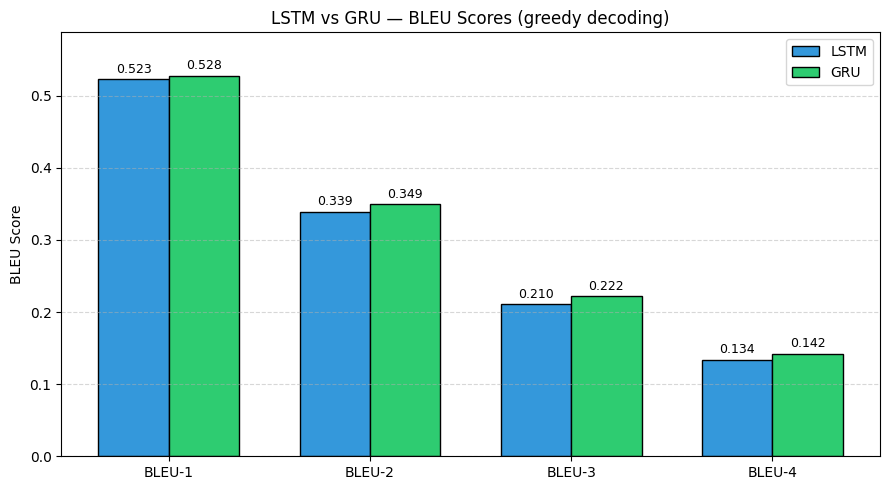

Plot saved to ../outputs/evaluation/bleu_comparison.png


In [13]:
labels = ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]
lstm_vals = [lstm_bleu[f"bleu_{i}"] for i in range(1, 5)]
gru_vals  = [gru_bleu[f"bleu_{i}"] for i in range(1, 5)]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, lstm_vals, w, label="LSTM", color="#3498db", edgecolor="black")
b2 = ax.bar(x + w/2, gru_vals,  w, label="GRU",  color="#2ecc71", edgecolor="black")

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("BLEU Score")
ax.set_title("LSTM vs GRU — BLEU Scores (greedy decoding)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_ylim(0, max(max(lstm_vals), max(gru_vals)) + 0.06)

plt.tight_layout()
plot_path = os.path.join(EVAL_DIR, "bleu_comparison.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved to {plot_path}")

### 7.2 Contoh Prediksi

Beberapa sampel prediksi ditampilkan untuk memberikan gambaran kualitatif tentang kualitas *caption* yang dihasilkan oleh kedua model.

In [14]:
n_show = 5
print(f"{'Image':<25} {'Model':<8} {'Caption':<45}")
print("=" * 78)
for i in range(n_show):
    img = test_image_list[i]
    ref = references[i][0]
    print(f"{img:<25} {'Ref':<8} {ref[:42]:<45}")
    print(f"{img:<25} {'LSTM':<8} {lstm_captions[i][:42]:<45}")
    print(f"{img:<25} {'GRU':<8} {gru_captions[i][:42]:<45}")
    print("-" * 78)

Image                     Model    Caption                                      
3139895886_5a6d495b13.jpg Ref      <start> a blackandwhite dog bounds off the   
3139895886_5a6d495b13.jpg LSTM     a black and white dog is running through a   
3139895886_5a6d495b13.jpg GRU      a black and white dog is running through a   
------------------------------------------------------------------------------
3133825703_359a0c414d.jpg Ref      <start> a child staring at santa <end>       
3133825703_359a0c414d.jpg LSTM     a man in a black shirt and a hat is standi   
3133825703_359a0c414d.jpg GRU      a man with a beard and a beard in a white    
------------------------------------------------------------------------------
244910177_7c4ec3f65b.jpg  Ref      <start> three woman walk down a city stree   
244910177_7c4ec3f65b.jpg  LSTM     a woman in a red shirt is standing in fron   
244910177_7c4ec3f65b.jpg  GRU      a woman in a pink shirt is standing next t   
--------------------------------

## Analisis Hasil dan Observasi

Berdasarkan hasil evaluasi, diperoleh temuan-temuan berikut:

1. **Perbandingan BLEU:** GRU konsisten mengungguli LSTM pada seluruh metrik BLEU (BLEU-1 hingga BLEU-4). Selisihnya kecil (~0.005-0.009) tetapi konsisten di semua metrik.

2. **BLEU-1 tertinggi** (~0.52-0.53) menunjukkan bahwa kedua model cukup baik dalam memilih kata yang tepat untuk mendeskripsikan gambar.

3. **BLEU-4 terendah** (~0.13-0.14) menunjukkan bahwa model masih kesulitan menghasilkan struktur kalimat yang persis dengan referensi manusia.

4. **Efisiensi GRU:** Dengan parameter ~8,4% lebih sedikit dan waktu pelatihan ~12% lebih cepat, GRU menghasilkan performa yang sebanding atau sedikit lebih baik dari LSTM pada dataset ini.

Tabel perbandingan lengkap:

| Metric | LSTM | GRU | Delta |
|--------|------|-----|-------|
| BLEU-1 | 0.5224 | 0.5293 | +0.0069 |
| BLEU-2 | 0.3406 | 0.3482 | +0.0076 |
| BLEU-3 | 0.2111 | 0.2201 | +0.0090 |
| BLEU-4 | 0.1331 | 0.1381 | +0.0050 |

## Ekspor

Tiga file disimpan untuk dokumentasi dan penggunaan selanjutnya:
- **`outputs/evaluation/bleu_scores.csv`** — Skor BLEU untuk kedua model;
- **`outputs/evaluation/bleu_comparison.png`** — Grafik perbandingan visual;
- **`outputs/evaluation/predictions.csv`** — Seluruh prediksi untuk 810 gambar data uji.

In [15]:
results = {
    "image": test_image_list,
    "reference": [references[i][0] for i in range(n_test)],
    "lstm_prediction": lstm_captions,
    "gru_prediction": gru_captions,
}
results_df = pd.DataFrame(results)
results_path = os.path.join(EVAL_DIR, "predictions.csv")
results_df.to_csv(results_path, index=False)
print(f"Predictions saved to {results_path}")

bleu_df = pd.DataFrame({
    "metric": [f"bleu_{i}" for i in range(1, 5)],
    "lstm": lstm_vals,
    "gru": gru_vals,
})
bleu_df["delta"] = bleu_df["gru"] - bleu_df["lstm"]
bleu_path = os.path.join(EVAL_DIR, "bleu_scores.csv")
bleu_df.to_csv(bleu_path, index=False)
print(f"BLEU scores saved to {bleu_path}")

print(f"\n{'Metric':<12} {'LSTM':<12} {'GRU':<12} {'Δ':<12}")
print("-" * 48)
for _, row in bleu_df.iterrows():
    print(f"{row['metric'].upper():<12} {row['lstm']:<12.4f} "
          f"{row['gru']:<12.4f} {row['delta']:<+12.4f}")

Predictions saved to ../outputs/evaluation/predictions.csv
BLEU scores saved to ../outputs/evaluation/bleu_scores.csv

Metric       LSTM         GRU          Δ           
------------------------------------------------
BLEU_1       0.5226       0.5278       +0.0052     
BLEU_2       0.3388       0.3492       +0.0104     
BLEU_3       0.2105       0.2217       +0.0112     
BLEU_4       0.1337       0.1419       +0.0082     


## Kesimpulan dan Tahap Selanjutnya

Evaluasi menunjukkan bahwa GRU sedikit lebih unggul dari LSTM pada seluruh metrik BLEU. Dengan parameter yang lebih sedikit dan waktu pelatihan yang lebih cepat, GRU menjadi pilihan yang lebih efisien untuk dataset Flickr8k.

**Tahap selanjutnya:** **[07_inference.ipynb](07_inference.ipynb)** — Demonstrasi inferensi interaktif dengan opsi *greedy decoding* dan *beam search*.